# 03_1. Python Curve Calibration and LGM Parameters

This companion notebook keeps the same broad topic as notebook 03, but strips the workflow back to Python-only
components. The emphasis is on programmatic quote inputs, fitted term structures, and the LGM parameter shape that
later drives the path simulation.

**Purpose**
- fit curves from Python-defined quotes only
- visualize how fitter choice changes the resulting term structure
- connect those fitted curves to a Python-native LGM parameter setup

**What you will learn**
- how to bootstrap a small multi-currency curve set without XML or external runs
- how to inspect zero-rate and forward-rate shape from the fitted grid
- how the LGM alpha and kappa term structures look before any calibration loop is added


In [1]:
from pathlib import Path
import os
import sys

def _find_repo_root(start: Path) -> Path:
    current = start.resolve()
    for candidate in (current, *current.parents):
        if (candidate / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists():
            return candidate
    repo_hint = Path("/Users/gordonlee/Documents/Engine")
    if (repo_hint / "Tools" / "PythonOreRunner" / "notebook_series" / "series_helpers.py").exists():
        return repo_hint
    raise RuntimeError("Could not locate the Engine repo root from the current notebook working directory")

REPO_ROOT = _find_repo_root(Path.cwd())
NOTEBOOK_DIR = REPO_ROOT / "Tools" / "PythonOreRunner" / "notebook_series"
for path in (NOTEBOOK_DIR, REPO_ROOT):
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

os.environ.setdefault("MPLCONFIGDIR", "/tmp/codex-mplconfig")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import series_helpers as nh

try:
    from IPython.display import display
except Exception:
    def display(obj):
        if hasattr(obj, "to_string"):
            print(obj.to_string())
        else:
            print(obj)

repo = nh.bootstrap_notebook_env(REPO_ROOT)
nh.apply_plot_style()
print(repo)


/Users/gordonlee/Documents/Engine


In [2]:
from py_ore_tools import (
    RateFutureModelParams,
    extract_market_instruments_by_currency_from_quotes,
    fit_discount_curves_from_programmatic_quotes,
    fitted_curves_to_dataframe,
    quote_dicts_from_pairs,
)

quote_pairs = [
    ("MM/RATE/USD/USD-LIBOR/1W", 0.0525),
    ("MM/RATE/USD/USD-LIBOR/1M", 0.0520),
    ("MM/RATE/USD/USD-LIBOR/3M", 0.0515),
    ("MM/RATE/USD/USD-LIBOR/6M", 0.0508),
    ("ZERO/RATE/USD/1Y", 0.0500),
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/1Y", 0.0494),
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/2Y", 0.0485),
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/3Y", 0.0479),
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/5Y", 0.0470),
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/7Y", 0.0462),
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/10Y", 0.0455),
    ("MM/RATE/EUR/EUR-EURIBOR/1W", 0.0315),
    ("MM/RATE/EUR/EUR-EURIBOR/1M", 0.0310),
    ("MM/RATE/EUR/EUR-EURIBOR/3M", 0.0307),
    ("ZERO/RATE/EUR/1Y", 0.0300),
    ("IR_SWAP/RATE/EUR/EUR-EURIBOR-6M/6M/1Y", 0.0304),
    ("IR_SWAP/RATE/EUR/EUR-EURIBOR-6M/6M/2Y", 0.0310),
    ("IR_SWAP/RATE/EUR/EUR-EURIBOR-6M/6M/3Y", 0.0314),
    ("IR_SWAP/RATE/EUR/EUR-EURIBOR-6M/6M/5Y", 0.0320),
    ("IR_SWAP/RATE/EUR/EUR-EURIBOR-6M/6M/7Y", 0.0325),
    ("IR_SWAP/RATE/EUR/EUR-EURIBOR-6M/6M/10Y", 0.0330),
    ("MM/RATE/GBP/GBP-LIBOR/1W", 0.0415),
    ("MM/RATE/GBP/GBP-LIBOR/1M", 0.0410),
    ("MM/RATE/GBP/GBP-LIBOR/3M", 0.0406),
    ("ZERO/RATE/GBP/1Y", 0.0405),
    ("IR_SWAP/RATE/GBP/GBP-LIBOR-6M/6M/1Y", 0.0400),
    ("IR_SWAP/RATE/GBP/GBP-LIBOR-6M/6M/2Y", 0.0398),
    ("IR_SWAP/RATE/GBP/GBP-LIBOR-6M/6M/3Y", 0.0395),
    ("IR_SWAP/RATE/GBP/GBP-LIBOR-6M/6M/5Y", 0.0391),
    ("IR_SWAP/RATE/GBP/GBP-LIBOR-6M/6M/7Y", 0.0388),
]
quote_dicts = quote_dicts_from_pairs(quote_pairs)
instruments = extract_market_instruments_by_currency_from_quotes(asof_date="2026-03-08", quotes=quote_dicts)
bootstrap_fit = fit_discount_curves_from_programmatic_quotes(
    asof_date="2026-03-08",
    quotes=quote_dicts,
    fit_method="bootstrap_mm_irs_v1",
    fit_grid_mode="dense",
    dense_step_years=0.25,
)
weighted_fit = fit_discount_curves_from_programmatic_quotes(
    asof_date="2026-03-08",
    quotes=quote_dicts,
    fit_method="weighted_zero_logdf_v1",
    fit_grid_mode="dense",
    dense_step_years=0.25,
)

bootstrap_df = fitted_curves_to_dataframe(bootstrap_fit)
weighted_df = fitted_curves_to_dataframe(weighted_fit)
display(pd.DataFrame(
    [
        {"ccy": ccy, "instrument_count": payload["instrument_count"], "fit_points": bootstrap_fit[ccy]["fit_points_count"]}
        for ccy, payload in sorted(instruments.items())
    ]
))
display(bootstrap_df.head(12))


,ccy,instrument_count,fit_points
0,EUR,10,41
1,GBP,9,29
2,USD,11,41


,ccy,asof_date,time,calendar_date,df,zero_rate,curve_method,instrument_count
0,EUR,2026-03-08,0.00,2026-03-08,1.000000,0.000000,bootstrap_mm_irs_v1,10
1,EUR,2026-03-08,0.25,2026-06-07,0.992354,0.030700,bootstrap_mm_irs_v1,10
2,EUR,2026-03-08,0.50,2026-09-06,0.984882,0.030467,bootstrap_mm_irs_v1,10
3,EUR,2026-03-08,0.75,2026-12-07,0.977580,0.030233,bootstrap_mm_irs_v1,10
4,EUR,2026-03-08,1.00,2027-03-08,0.970446,0.030000,bootstrap_mm_irs_v1,10
5,EUR,2026-03-08,1.25,2027-06-07,0.963033,0.030134,bootstrap_mm_irs_v1,10
6,EUR,2026-03-08,1.50,2027-09-07,0.955612,0.030269,bootstrap_mm_irs_v1,10
7,EUR,2026-03-08,1.75,2027-12-07,0.948185,0.030403,bootstrap_mm_irs_v1,10
8,EUR,2026-03-08,2.00,2028-03-07,0.940753,0.030537,bootstrap_mm_irs_v1,10
9,EUR,2026-03-08,2.25,2028-06-06,0.933389,0.030637,bootstrap_mm_irs_v1,10


## Programmatic market inputs

The input set is intentionally small. The point is not market realism; it is to make the mapping from quote mix to
fitted curve visible without hiding behind file loading or a large case bundle.


,ccy,quote_key,quote_value,instrument_type
0,USD,MM/RATE/USD/USD-LIBOR/1W,0.0525,MM
1,USD,MM/RATE/USD/USD-LIBOR/1M,0.0520,MM
2,USD,MM/RATE/USD/USD-LIBOR/3M,0.0515,MM
3,USD,MM/RATE/USD/USD-LIBOR/6M,0.0508,MM
4,USD,ZERO/RATE/USD/1Y,0.0500,ZERO
5,USD,IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/1Y,0.0494,IR_SWAP
6,USD,IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/2Y,0.0485,IR_SWAP
7,USD,IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/3Y,0.0479,IR_SWAP
8,USD,IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/5Y,0.0470,IR_SWAP
9,USD,IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/7Y,0.0462,IR_SWAP


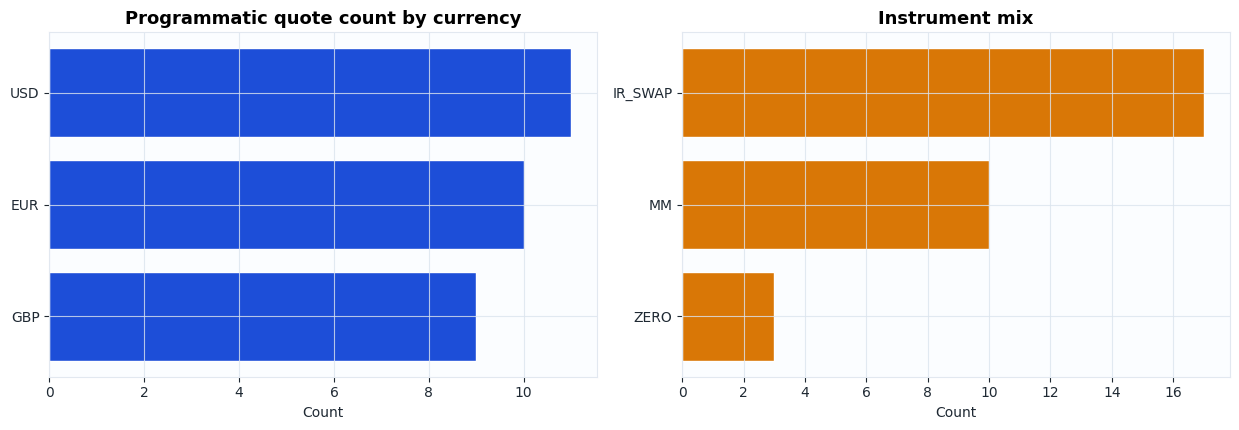

In [3]:
input_rows = []
for quote in quote_dicts:
    key = str(quote["key"])
    parts = key.split("/")
    input_rows.append(
        {
            "ccy": parts[2] if len(parts) > 2 else "",
            "quote_key": key,
            "quote_value": quote.get("value"),
            "instrument_type": parts[0] if parts else "",
        }
    )
input_df = pd.DataFrame(input_rows)
display(input_df)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
nh.plot_ranked_bars(
    input_df.groupby("ccy", as_index=False).size().rename(columns={"size": "count"}),
    "ccy",
    "count",
    title="Programmatic quote count by currency",
    color=nh.PALETTE["blue"],
    ax=axes[0],
)
nh.plot_ranked_bars(
    input_df.groupby("instrument_type", as_index=False).size().rename(columns={"size": "count"}),
    "instrument_type",
    "count",
    title="Instrument mix",
    color=nh.PALETTE["gold"],
    ax=axes[1],
)
plt.tight_layout()
plt.show()
plt.close(fig)


## Fitted curves

Two fitters are shown on the same quotes because that is the smallest useful comparison. It separates the market
input choice from the interpolation / fitting choice.


,ccy,fit_points,min_df,max_df
0,EUR,41,0.719597,1.0
1,GBP,29,0.765391,1.0
2,USD,41,0.638780,1.0


,ccy,fit_points,min_df,max_df
0,EUR,41,0.718924,1.0
1,GBP,29,0.762159,1.0
2,USD,41,0.634448,1.0


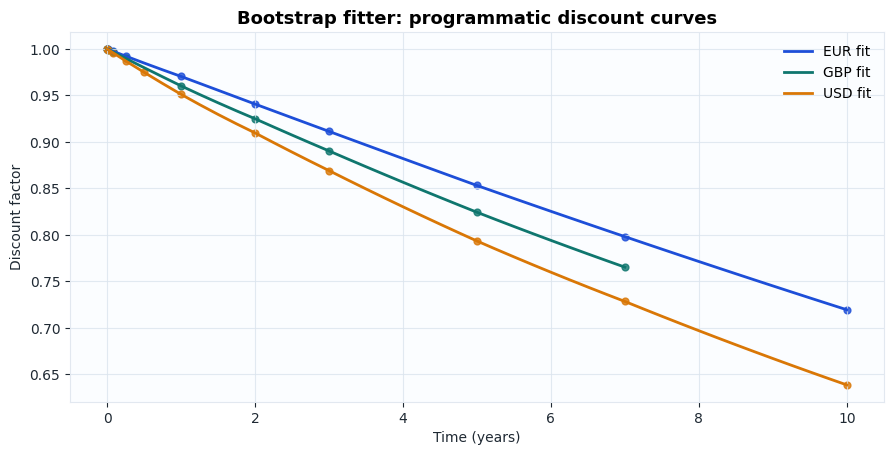

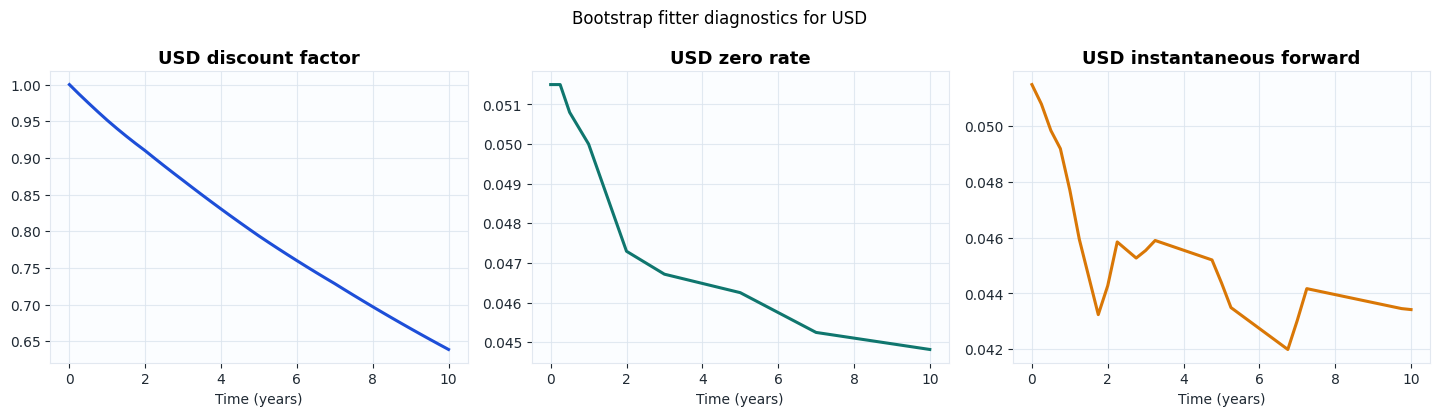

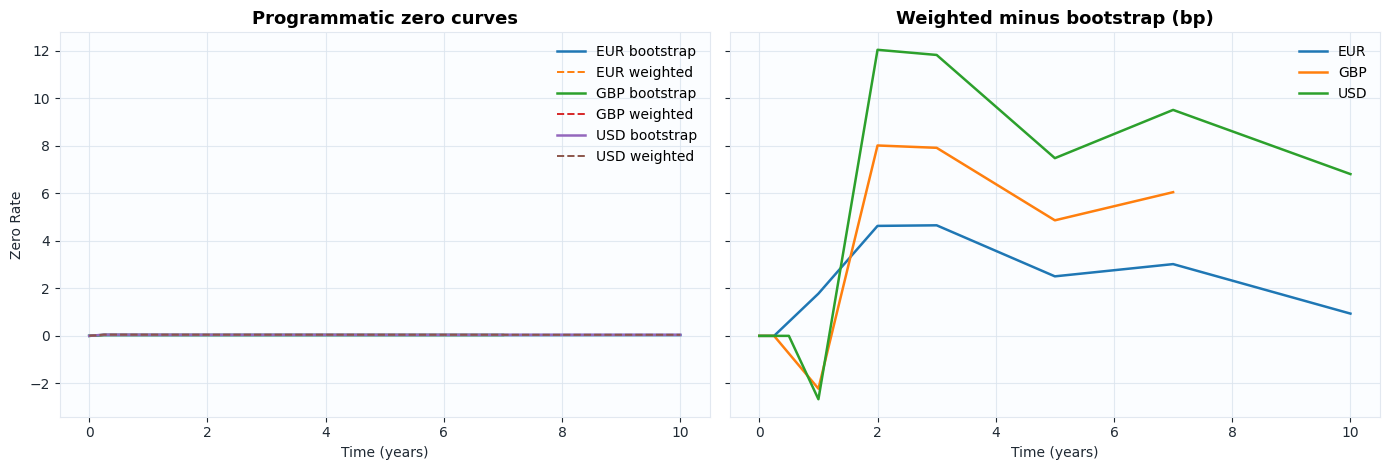

In [4]:
bootstrap_summary = (
    bootstrap_df.groupby("ccy", as_index=False)
    .agg(fit_points=("time", "count"), min_df=("df", "min"), max_df=("df", "max"))
    .sort_values("ccy")
)
weighted_summary = (
    weighted_df.groupby("ccy", as_index=False)
    .agg(fit_points=("time", "count"), min_df=("df", "min"), max_df=("df", "max"))
    .sort_values("ccy")
)
display(bootstrap_summary)
display(weighted_summary)

nh.plot_fitted_curves(bootstrap_fit, title="Bootstrap fitter: programmatic discount curves")
nh.plot_curve_diagnostics(bootstrap_df, ccy="USD", title="Bootstrap fitter diagnostics for USD")

sample_ccys = sorted(set(bootstrap_df["ccy"]))[:3]
fig, axes = plt.subplots(1, 2, figsize=(14, 4.8), sharey=True)
for ccy in sample_ccys:
    b = bootstrap_df[bootstrap_df["ccy"] == ccy].sort_values("time")
    w = weighted_df[weighted_df["ccy"] == ccy].sort_values("time")
    axes[0].plot(b["time"], b["zero_rate"], linewidth=1.8, label=f"{ccy} bootstrap")
    axes[0].plot(w["time"], w["zero_rate"], linewidth=1.4, linestyle="--", label=f"{ccy} weighted")
    axes[1].plot(b["time"], 1.0e4 * (w["zero_rate"].to_numpy() - b["zero_rate"].to_numpy()), linewidth=1.8, label=ccy)
axes[0].set_title("Programmatic zero curves")
axes[0].set_xlabel("Time (years)")
axes[0].set_ylabel("Zero Rate")
axes[0].legend()
axes[1].set_title("Weighted minus bootstrap (bp)")
axes[1].set_xlabel("Time (years)")
axes[1].legend()
plt.tight_layout()
plt.show()
plt.close(fig)


The second panel is the one to read closely. If the difference stays small and smooth, the notebook is showing a
fitter-choice effect rather than evidence of broken market inputs.


## Rates futures and convexity

The bootstrap fitter also supports rates futures. There are two Python modes:

- `external_adjusted_fra`: convert the futures price into an adjusted forward before fitting
- `native_future`: keep the instrument tagged as a future and apply the same convexity engine inside the bootstrap

Today those two paths share one convexity implementation, which is the migration-friendly setup if the ORE-compatible
path needs to stay in place while the Python-native future instrument matures.


In [5]:
future_quotes = [
    ("MM/RATE/USD/USD-LIBOR/1W", 0.0255),
    ("MM/RATE/USD/USD-LIBOR/1M", 0.0200),
    ("MM/RATE/USD/USD-LIBOR/3M", 0.0210),
    {
        "key": "MM_FUTURE/PRICE/USD/2020-08/ED/3M",
        "value": 97.55,
        "contract_start": "2020-08-19",
        "contract_end": "2020-11-19",
        "convexity_adjustment": 0.0010,
    },
    {
        "key": "MM_FUTURE/PRICE/USD/2020-09/ED/3M",
        "value": 97.47,
        "contract_start": "2020-09-16",
        "contract_end": "2020-12-16",
        "convexity_adjustment": 0.0009,
    },
    {
        "key": "MM_FUTURE/PRICE/USD/2020-12/ED/3M",
        "value": 97.38,
        "contract_start": "2020-12-16",
        "contract_end": "2021-03-17",
        "convexity_adjustment": 0.0008,
    },
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/1Y", 0.0230),
    ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/2Y", 0.0240),
]

future_external = fit_discount_curves_from_programmatic_quotes(
    asof_date="2020-05-15",
    quotes=future_quotes,
    instrument_types=("MM", "IR_SWAP", "FUTURE"),
    fit_method="bootstrap_mm_irs_v1",
    fit_grid_mode="instrument",
    future_convexity_mode="external_adjusted_fra",
)
future_native = fit_discount_curves_from_programmatic_quotes(
    asof_date="2020-05-15",
    quotes=future_quotes,
    instrument_types=("MM", "IR_SWAP", "FUTURE"),
    fit_method="bootstrap_mm_irs_v1",
    fit_grid_mode="instrument",
    future_convexity_mode="native_future",
)
future_model = fit_discount_curves_from_programmatic_quotes(
    asof_date="2020-05-15",
    quotes=[
        ("MM/RATE/USD/USD-LIBOR/1W", 0.0255),
        ("MM/RATE/USD/USD-LIBOR/1M", 0.0200),
        ("MM/RATE/USD/USD-LIBOR/3M", 0.0210),
        ("MM_FUTURE/PRICE/USD/2020-08/ED/3M", 97.55),
        ("MM_FUTURE/PRICE/USD/2020-09/ED/3M", 97.47),
        ("MM_FUTURE/PRICE/USD/2020-12/ED/3M", 97.38),
        ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/1Y", 0.0230),
        ("IR_SWAP/RATE/USD/USD-LIBOR-3M/3M/2Y", 0.0240),
    ],
    instrument_types=("MM", "IR_SWAP", "FUTURE"),
    fit_method="bootstrap_mm_irs_v1",
    fit_grid_mode="instrument",
    future_convexity_mode="native_future",
    future_model_params=RateFutureModelParams(model="hw", mean_reversion=0.03, volatility=0.01),
)

future_diag = pd.DataFrame(
    [
        future_external["USD"]["bootstrap_diagnostics"][0],
        future_native["USD"]["bootstrap_diagnostics"][0],
        future_model["USD"]["bootstrap_diagnostics"][0],
    ]
)
display(future_diag)

future_curve_df = pd.DataFrame(
    {
        "time": future_external["USD"]["times"],
        "df_external_adjusted_fra": future_external["USD"]["dfs"],
        "df_native_future": future_native["USD"]["dfs"],
    }
)
display(future_curve_df)


,instrument_type,pricing_mode,quote_key,contract_start,contract_end,start_time,end_time,price,futures_rate,convexity_adjustment,adjusted_forward_rate
0,MM_FUTURE,external_adjusted_fra,MM_FUTURE/PRICE/USD/2020-08/ED/3M,2020-08-19,2020-11-19,0.263014,0.515068,97.55,0.0245,1.000000e-03,0.023500
1,MM_FUTURE,native_future,MM_FUTURE/PRICE/USD/2020-08/ED/3M,2020-08-19,2020-11-19,0.263014,0.515068,97.55,0.0245,1.000000e-03,0.023500
2,MM_FUTURE,native_future,MM_FUTURE/PRICE/USD/2020-08/ED/3M,2020-08-01,2020-11-01,0.213699,0.465753,97.55,0.0245,6.694197e-07,0.024499


,time,df_external_adjusted_fra,df_native_future
0,0.000000,1.000000,1.000000
1,0.019231,0.999510,0.999510
2,0.083333,0.998335,0.998335
3,0.250000,0.994764,0.994764
4,0.515068,0.988906,0.988906
5,0.589041,0.986774,0.986774
6,0.838356,0.980565,0.980565
7,1.000000,0.977517,0.977517
8,2.000000,0.953652,0.953652


,alpha_time,alpha_value,kappa_time,kappa_value
0,0.5,0.010,1.0,0.040
1,1.0,0.013,3.0,0.030
2,2.0,0.017,terminal,0.022
3,4.0,0.016,NaN,NaN
4,terminal,0.013,NaN,NaN


,bucket,alpha
0,0,0.010
1,1,0.013
2,2,0.017
3,3,0.016
4,4,0.013


,bucket,kappa
0,0,0.040
1,1,0.030
2,2,0.022


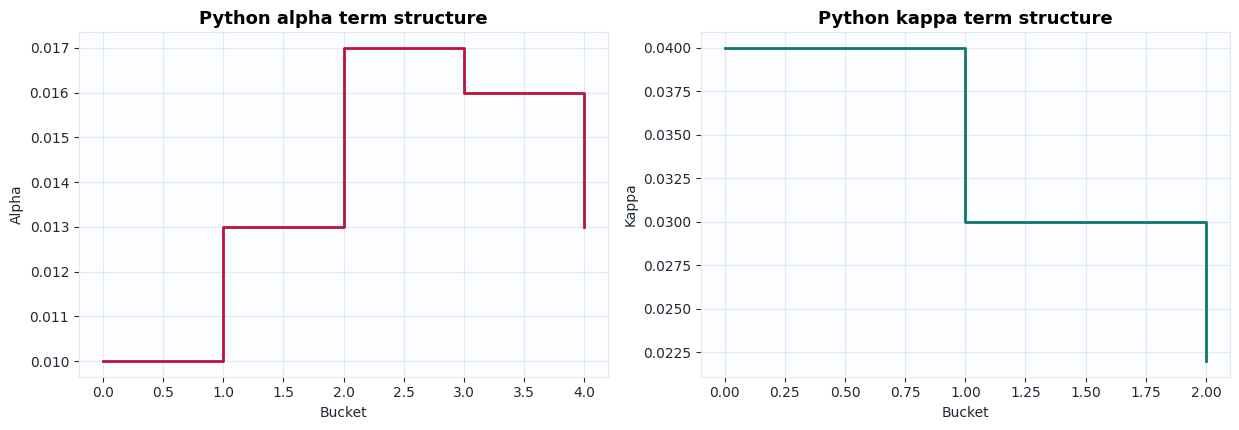

In [6]:
demo = nh.run_python_lgm_demo(seed=42, n_paths=512)
param_frame = nh.lgm_params_frame(demo["params"])
display(param_frame)

alpha_frame = pd.DataFrame(
    {
        "bucket": range(len(demo["params"].alpha_values)),
        "alpha": list(demo["params"].alpha_values),
    }
)
kappa_frame = pd.DataFrame(
    {
        "bucket": range(len(demo["params"].kappa_values)),
        "kappa": list(demo["params"].kappa_values),
    }
)
display(alpha_frame)
display(kappa_frame)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.4))
axes[0].step(range(len(alpha_frame)), alpha_frame["alpha"], where="post", linewidth=2.0, color=nh.PALETTE["rose"])
axes[0].set_title("Python alpha term structure")
axes[0].set_xlabel("Bucket")
axes[0].set_ylabel("Alpha")
axes[1].step(range(len(kappa_frame)), kappa_frame["kappa"], where="post", linewidth=2.0, color=nh.PALETTE["teal"])
axes[1].set_title("Python kappa term structure")
axes[1].set_xlabel("Bucket")
axes[1].set_ylabel("Kappa")
plt.tight_layout()
plt.show()
plt.close(fig)


## Key takeaways

- Programmatic quotes are enough to teach the fitter workflow cleanly.
- The fitting method changes the curve shape more subtly than the quote mix does.
- The LGM parameter tables can be inspected as ordinary Python data before any larger workflow is built on top.
